# 样章 · 平衡、负反馈与参数变化

## 学习目标与先修知识

完成后，你能求出平衡（equilibrium），用负反馈（negative feedback）解释被动调节，并分别比较最终存量（stock）与靠近平衡的速度。

**先修知识**：[用 Python 表达积累与清除](02-accumulation-clearance.ipynb)中的递推关系（recurrence relation），以及代数运算。


## 具体问题

持续输入为什么没有让默认轨迹无限上升？如果初始存量高于平衡，会发生什么？
先看一组流率：当 A = 1、2、3 U 时，流入始终为 1 U/T，而清除依次为 0.5、1、1.5 U/T。

## 初步实验

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
from systems_science.theme import DATA_COLORS, SERIES_COLORS

plot_style()

In [2]:
trial_amounts = [1.0, 2.0, 3.0]
display(Markdown(show_table(["A / U", "u / (U/T)", "kA / (U/T)", "净流入 / (U/T)"],
                           [[a, 1, 0.5*a, 1-0.5*a] for a in trial_amounts])))

| A / U | u / (U/T) | kA / (U/T) | 净流入 / (U/T) |
| --- | --- | --- | --- |
| 1 | 1 | 0.5 | 0.5 |
| 2 | 1 | 1 | 0 |
| 3 | 1 | 1.5 | -0.5 |

## 模型假设

把研究对象看成一个**充分混合的单室模型（one-compartment model）**：用一个数描述室内示踪物质（tracer）总量。
示踪物质只是便于思考的标记物。本单元使用人工单位 U 与 T，参数（parameter）是教学选择，
不对应具体药物、患者或真实生理测量。边界外的输入被视为已知；不讨论组织容积、
浓度（concentration）、多室交换或观测噪声。A 是物质量，不是浓度。

| 量 | 含义 | 单位与条件 |
|---|---|---|
| $t$ | 从实验起点经过的时间 | T，$t\geq0$ |
| $A$、$A_0$ | 当前与初始物质量 | U，连续模型非负 |
| $u$ | 流入速率 | U/T，非负 |
| $k$ | 比例清除系数（elimination rate constant） | 1/T，非负 |
| $h$ | 计算时间步长（time step） | T，正数 |

假设清除速率为 $kA$，单位是 U/T。这个比例关系是一项建模假设，
不代表所有物质在任意条件下都按同一机制清除。

## 数学解释与推导

平衡要求存量不再变化，即流入与清除相等：$u-kA_*=0$。
当 $k>0$，得到 $A_*=u/k$，单位为 $(U/T)/(1/T)=U$。

- $A<A_*$：净流入为正，存量上升。
- $A>A_*$：清除超过流入，存量下降。
- $A=A_*$：仍有流动，但净流入为零。

A 上升 → kA 上升 → 净流入减少，这是一种负反馈结构。
这里没有传感器、目标设定或控制器；被动清除本身已经能产生自平衡趋势。

改变 k 同时改变平衡位置与动态过程。若只想比较“靠近的快慢”，
就比较相对各自平衡的偏差，而不要只看两条处于不同高度的曲线。
若 k = 0，公式 u/k 无意义：u > 0 时一直积累，u = 0 时每个初值（initial condition）都保持不变。

## 核心实现

用更新循环观察接近平衡的过程。平衡位置可以由代数关系独立求得。

In [3]:
def euler(u=1.0, k=0.5, A0=0.0, h=0.1, duration=20.0):
    """恒定输入下的显式 Euler；保留负值以识别数值失败。"""
    if not all(np.isfinite(v) for v in (u, k, A0, h, duration)):
        raise ValueError("参数必须是有限数")
    if min(u, k, A0) < 0 or h <= 0 or duration <= 0:
        raise ValueError("输入、清除和初值非负，步长与时长为正")
    n_steps = round(duration / h)
    if n_steps < 1 or not np.isclose(n_steps * h, duration, rtol=0, atol=1e-10):
        raise ValueError("本节要求步长整除观察时长；分段步长见 S06")
    times = np.linspace(0.0, duration, n_steps + 1)
    amounts = np.empty(n_steps + 1)
    amounts[0] = A0
    for n in range(n_steps):
        dt = times[n + 1] - times[n]
        inflow = u * dt
        outflow = k * amounts[n] * dt
        amounts[n + 1] = amounts[n] + inflow - outflow
    if not np.all(np.isfinite(amounts)):
        raise FloatingPointError("数值结果非有限，请检查步长")
    return times, amounts

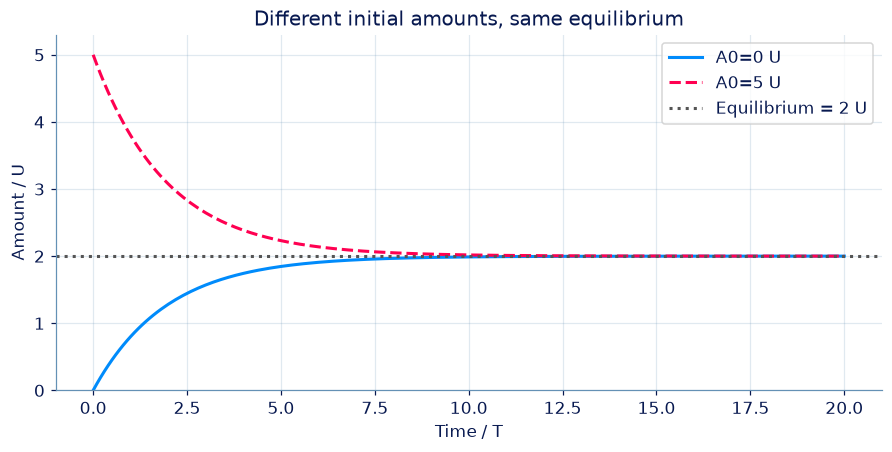

In [4]:
u, k = 1.0, 0.5
equilibrium = u / k
fig, ax = plt.subplots()
for initial, style in [(0.0, "-"), (5.0, "--")]:
    t, a = euler(A0=initial)
    ax.plot(t, a, style, label=f"A0={initial:g} U")
ax.axhline(equilibrium, color=SERIES_COLORS["reference"], linestyle=":", label="Equilibrium = 2 U")
ax.set(xlabel="Time / T", ylabel="Amount / U", title="Different initial amounts, same equilibrium", ylim=(0, 5.3))
ax.legend()
plt.show()
_, at_equilibrium = euler(A0=equilibrium)
assert np.allclose(at_equilibrium, equilibrium)

## 对照实验

左图改变 k 而保持 u = 1，平衡随之变化；右图显示“偏差 / 初始偏差”，
起点统一为 1、接近平衡时趋于 0，让靠近速度更容易比较。

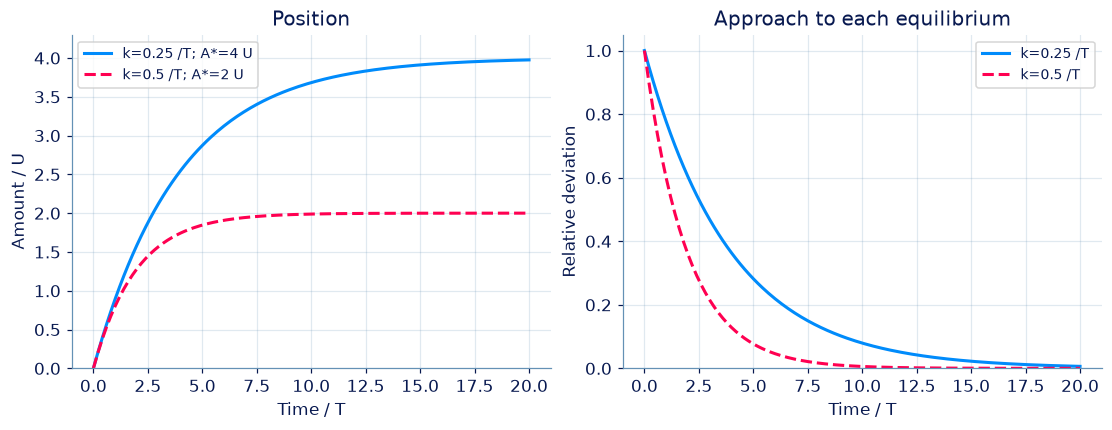

| 边界情形 | 20 T 时存量 / U |
| --- | --- |
| 无清除 | 22 |
| 无流入 | 7.01053e-05 |
| 两者皆无 | 2 |

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for clearance, style in [(0.25, "-"), (0.5, "--")]:
    t, a = euler(k=clearance)
    target = 1.0 / clearance
    axes[0].plot(t, a, style, label=f"k={clearance:g} /T; A*={target:g} U")
    axes[1].plot(t, (a - target) / (0 - target), style, label=f"k={clearance:g} /T")
axes[0].set(xlabel="Time / T", ylabel="Amount / U", title="Position", ylim=(0, 4.3))
axes[1].set(xlabel="Time / T", ylabel="Relative deviation", title="Approach to each equilibrium", ylim=(0, 1.05))
for ax in axes: ax.legend(fontsize=9)
plt.show()
t, no_clearance = euler(k=0, A0=2)
assert np.allclose(no_clearance, 2 + t)
_, no_input = euler(u=0, A0=2)
assert np.all(np.diff(no_input) <= 0)
_, no_flow = euler(u=0, k=0, A0=2)
assert np.all(no_flow == 2)
display(Markdown(show_table(["边界情形", "20 T 时存量 / U"],
                           [["无清除", no_clearance[-1]], ["无流入", no_input[-1]], ["两者皆无", no_flow[-1]]])))

## 结果解释

不同初值靠近相同的 2 U 平衡；减小 k 使平衡提高，同时减慢相对偏差的消退。
“更高的最终存量”和“更慢的靠近速度”是两个不同问题。无清除而有输入时，存量持续增加。
上述数值图使用较小步长；方向判断来自净流率的符号，尚不能用它为任意大步长的程序作保证。

## 练习与参考资料

先独立作答，再提交核对。每道题的题面和输入输出示例如下。

### 第 1 题 · 单项选择题：平衡时是否还有物质交换

恒定输入 u=1 U/T、k=0.5 /T、存量（stock） A=2 U。系统处于平衡（equilibrium）。哪项正确？

- **A.** 流入与清除都为 1 U/T，净流入为零
- **B.** 没有流入，也没有清除
- **C.** 平衡只可能出现在 A=0
- **D.** 因为有物质交换，所以存量一定增加

[作答：平衡时是否还有物质交换](http://127.0.0.1:8000/samples/accumulation-clearance/practice/?question=exchange-at-equilibrium)

### 第 2 题 · Python 计算题：在同一平衡位置比较靠近速度

保持平衡（equilibrium）位置 target 不变，对每个 k 令 u=k·target。从 A0=0 出发，计算离散更新首次达到 fraction·target 的时刻。

**函数与代码模板**

```python
def solve(
    target: float,
    ks: list[float],
    h: float,
    fraction: float,
) -> tuple[list[float], list[float]]:
    # 依次返回 inputs, first_times。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `target` | `float` | 各次实验共同的平衡物质量。 | U |
| `ks` | `list[float]` | 要逐一比较的清除系数（elimination rate constant）；顺序也是结果的顺序。 | 1/T |
| `h` | `float` | 每次更新跨过的时间间隔。 | T |
| `fraction` | `float` | 需要达到 target 的比例；例如 0.5 表示达到一半。 | 无量纲 |

**返回值**

按以下顺序返回元组：(inputs, first_times)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `inputs` | `list[float]` | inputs[i] 是与 ks[i] 对应的恒定流入速率。 | U/T |
| `first_times` | `list[float]` | first_times[i] 是首次满足 A ≥ fraction·target 的离散时刻。 | T |

**计算规则**

对每个 k=ks[i]，先令 u=k·target，再独立从 A=0 开始按 A_next=A+h·(u−k·A) 更新。第一次达到或超过 fraction·target 时，记录更新次数×h。依次返回 (inputs, first_times)。

**约束与边界**

- 0 < target ≤ 100；ks 有 1 到 20 项，每项 0 < k ≤ 1。
- 0 < h ≤ 1，0 < fraction < 1，所有 k·h ≤ 1；给定条件保证 10000 步内到达阈值。
- 两个返回列表与 ks 等长。每个实验都重新从零开始；返回网格上的首次到达时刻，不以连续时间公式代替。

**输入样例**

以下是一组传给 solve 的参数；U、T 分别是物质量与时间单位。每个参数直接对应上方函数签名中的同名变量。

给定条件

| 量的含义 | 函数参数 | 给定值 | 单位 |
| --- | --- | --- | --- |
| 共同的平衡物质量 | target | 2 | U |
| 时间步长 | h | 0.1 | T |
| 需要达到的平衡比例 | fraction | 0.5 | 1 |

分别比较两种清除快慢

| 实验 | 清除系数 ks / (1/T) |
| --- | --- |
| 1 | 0.25 |
| 2 | 0.5 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
target = 2
ks = [0.25, 0.5]
h = 0.1
fraction = 0.5

result = solve(target, ks, h, fraction)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

按输入中的清除系数顺序返回

| 清除系数 / (1/T) | 所需流入 inputs / (U/T) | 首次到达时刻 first_times / T |
| --- | --- | --- |
| 0.25 | 0.5 | 2.8 |
| 0.5 | 1 | 1.4 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([0.5, 1.0],
                   [2.8000000000000003, 1.4000000000000001])
```

**样例解释**

target=2 时，两种清除系数所需流入分别为 0.5 和 1 U/T。目标是首次达到 1 U；离散更新分别需要 28 步和 14 步，时刻为 2.8 T 和 1.4 T。

数值核验允许绝对误差 1e-08 或相对误差 1e-07；允许使用 Python 标准库。

[作答：在同一平衡位置比较靠近速度](http://127.0.0.1:8000/samples/accumulation-clearance/practice/?question=approach-speed)

### 第 3 题 · 多项选择题：零清除与改变流出机制

理想单室模型（one-compartment model）满足 A′=u−kA。哪些判断成立？选择所有正确项。

- **A.** k=0、u>0 时不存在有限平衡（equilibrium）存量（stock）
- **B.** k=u=0 时所有初值（initial condition）都保持不变
- **C.** 流出改成存量的平方根后，仍可直接套用 A*=u/k
- **D.** 被动清除可以形成负反馈（negative feedback），不要求已设计主动控制器

[作答：零清除与改变流出机制](http://127.0.0.1:8000/samples/accumulation-clearance/practice/?question=zero-clearance)

**进一步阅读**：[MIT 一阶线性微分方程](https://ocw.mit.edu/courses/18-03sc-differential-equations-fall-2011/pages/unit-i-first-order-differential-equations/first-order-linear-odes/)：后续连续模型的参考。本节讲解、推导组织和代码为本项目编写。

[下一节：从变化率进入微分方程](04-rates-ode.ipynb) · [单元目录](README.md)


[观察存量与流量](http://127.0.0.1:8000/samples/accumulation-clearance/explore/#stock-flow) · [比较步长与数值误差](http://127.0.0.1:8000/samples/accumulation-clearance/explore/#step-size) · [学习指南](../../../docs/学习指南.md)
